In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
audio_features = [
    "stft", "melspectrogram", "mfcc", "cqt", "vqt",
    "tonnetz", "spectral", "pseudo_cqt", "hybrid_cqt", "iirt"
]

distance_measures = [
    "itakura_saito", "beta_divergence", "cosh", "kl_divergence",
    "js_divergence", "manhattan", "euclidean", "chebyshev",
    "wasserstein", "cosine"
]

In [3]:
import numpy as np

def is_zero_fitness(f, tol=1e-6):
    """
    Works for any-dimensional fitness vector.
    Handles lists, tuples, numpy arrays.
    """
    try:
        return np.all(np.abs(f) < tol)
    except Exception:
        return False

In [4]:
import os
import pickle
import pandas as pd

data_base_dir = os.path.join("experiments", "ground_truth_scan")

# Load ground truth dataset 
with open(os.path.join(data_base_dir, "ground_truth_dataset.pkl"), "rb") as f:
    restored_individuals = pickle.load(f)

# Collect results
pop_analysis = []
fitness_labels = []
correct_matrix = []
recall_matrix = []

for feature in audio_features:
    for dist in distance_measures:
        pop_file = os.path.join(
            data_base_dir,
            feature,
            f"{feature}_{dist}_populations.pkl"
        )

        if not os.path.exists(pop_file):
            print(f"Warning: {pop_file} not found")
            continue

        with open(pop_file, "rb") as f:
            result_logs = pickle.load(f)  

        correct_ids = []
        f_correct_ids = []
        recall_ids = []
        recall_flags = np.zeros(len(restored_individuals), dtype=int)
        correct_flags = np.zeros(len(restored_individuals), dtype=int)
        total = len(result_logs)

        for idx, pop in result_logs:
            gt_ind = restored_individuals[idx]
            best_ind = max(pop.individuals, key=lambda ind: ind.fitness)

            gt_annotations   = {(s.instrument, s.pitch) for s in gt_ind.samples}
            best_annotations = {(s.instrument, s.pitch) for s in best_ind.samples}

            if any({(s.instrument, s.pitch) for s in ind.samples} == gt_annotations for ind in pop.individuals):
                recall_ids.append(idx)
                recall_flags[idx] = 1
            if best_annotations == gt_annotations:
                correct_ids.append(idx)
                correct_flags[idx] = 1
            if any(ind.fitness == 0 for ind in pop.individuals):
                f_correct_ids.append(idx)
                
        accuracy = len(correct_ids) / total if total > 0 else 0.0
        recall = len(recall_ids) / total if total > 0 else 0.0
        f0 = len(f_correct_ids) / total if total > 0 else 0.0
        correct_matrix.append(correct_flags)
        fitness_labels.append((feature, dist))
        recall_matrix.append(recall_flags)
        pop_analysis.append({
            "audio_feature": feature,
            "distance": dist,
            "total": total,
            "0 fitness": f0,
            "accuracy": accuracy,
            "recall": recall,
            "correct_ids": correct_ids,
            "recall_ids": recall_ids
        })

pop_df = pd.DataFrame(pop_analysis)

# Sort by accuracy
pop_df = pop_df.sort_values(by="accuracy", ascending=False)

print(pop_df[["audio_feature", "distance", "0 fitness", "accuracy", "recall"]])


   audio_feature       distance  0 fitness  accuracy  recall
3           stft  kl_divergence       0.00      0.67    0.70
4           stft  js_divergence       0.00      0.62    0.70
2           stft           cosh       0.00      0.57    0.65
32           cqt           cosh       0.03      0.55    0.58
82    hybrid_cqt           cosh       0.01      0.55    0.58
..           ...            ...        ...       ...     ...
65      spectral      manhattan       0.00      0.00    0.00
53       tonnetz  kl_divergence       0.00      0.00    0.01
63      spectral  kl_divergence       0.00      0.00    0.00
28          mfcc    wasserstein       0.00      0.00    0.00
69      spectral         cosine       0.00      0.00    0.00

[100 rows x 5 columns]


In [5]:
import os
import pickle
import pandas as pd

# === 1. Directories ===
ea_dir  = os.path.join("experiments", "ground_truth_scan")
moea_dir = os.path.join("experiments", "moea")

# === 2. Load ground truth dataset (same as EA) ===
with open(os.path.join(ea_dir, "ground_truth_dataset.pkl"), "rb") as f:
    restored_individuals = pickle.load(f)

# === 3. Define the MOEA configurations available ===
moea_population_files = [
    "stft_kl_divergence_stft_js_divergence_populations.pkl",
    "stft_kl_divergence_stft_js_divergence_hpc_populations.pkl",
    "stft_kl_divergence_pseudo_cqt_js_divergence_populations.pkl",
    "stft_kl_divergence_pseudo_cqt_js_divergence_stft_cosh_stft_js_divergence_iirt_js_divergence_populations.pkl"
]

# === 4. Parse file names → extract feature + objectives ===
def parse_moea_filename(filename):
    name = filename.replace("_populations.pkl", "")
    parts = name.split("_")
    feature = parts[0]   
    objectives = "_".join(parts)
    return feature, objectives


# === 5. Load MOEA and compute accuracy ===
moea_analysis = []

for fname in moea_population_files:
    fpath = os.path.join(moea_dir, fname)
    if not os.path.exists(fpath):
        print(f"Warning: MOEA file {fname} not found")
        continue

    with open(fpath, "rb") as f:
        result_logs = pickle.load(f)  

    # Extract descriptors
    feature, objectives = parse_moea_filename(fname)

    correct_ids = []
    total = len(result_logs)

    for idx, pop in result_logs:
        gt_ind = restored_individuals[idx]
        gt_annotations = {(s.instrument, s.pitch) for s in gt_ind.samples}
        if any({(s.instrument, s.pitch) for s in ind.samples} == gt_annotations for ind in pop.individuals):
            correct_ids.append(idx)

    recall = len(correct_ids) / total if total > 0 else 0.0

    moea_analysis.append({
        "audio_feature": feature,
        "objectives": objectives,
        "total": total,
        "correct": len(correct_ids),
        "recall": recall,
        "correct_ids": correct_ids
    })

moea_df = pd.DataFrame(moea_analysis)
moea_df = moea_df.sort_values(by="recall", ascending=False)

print("\n=== MOEA Accuracy ===")
print(moea_df[["objectives", "recall"]])



=== MOEA Accuracy ===
                                          objectives  recall
3  stft_kl_divergence_pseudo_cqt_js_divergence_st...    0.74
1          stft_kl_divergence_stft_js_divergence_hpc    0.72
2        stft_kl_divergence_pseudo_cqt_js_divergence    0.70
0              stft_kl_divergence_stft_js_divergence    0.65


In [6]:
# Harmonize column names for comparison
ea_df = pop_df.copy()
ea_df["objectives"] = ea_df.apply(
    lambda r: f"{r['audio_feature']}_{r['distance']}",
    axis=1
)

# Create a combined report
comparison = {
    "algorithm": ["EA"] * len(ea_df) + ["NSGA3"] * len(moea_df),
    "objectives": list(ea_df["objectives"]) + list(
        moea_df.apply(lambda r: f"{r['objectives']}", axis=1)
    ),
    "recall": list(ea_df["recall"]) + list(moea_df["recall"])
}

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values(by="recall", ascending=False)
comparison_df.to_csv("recall.csv", index=False)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print("\n=== EA vs MOEA Recall ===")
print(comparison_df)



=== EA vs MOEA Recall ===
    algorithm                                         objectives  recall
100     NSGA3  stft_kl_divergence_pseudo_cqt_js_divergence_st...    0.74
101     NSGA3          stft_kl_divergence_stft_js_divergence_hpc    0.72
0          EA                                 stft_kl_divergence    0.70
1          EA                                 stft_js_divergence    0.70
102     NSGA3        stft_kl_divergence_pseudo_cqt_js_divergence    0.70
103     NSGA3              stft_kl_divergence_stft_js_divergence    0.65
2          EA                                          stft_cosh    0.65
6          EA                                          iirt_cosh    0.63
5          EA                                  cqt_kl_divergence    0.60
7          EA                                melspectrogram_cosh    0.59
4          EA                                    hybrid_cqt_cosh    0.58
3          EA                                           cqt_cosh    0.58
9          EA           

In [7]:
import os
import pandas as pd

def load_experiment_csvs(base_dir, algorithm_label):
    """
    Returns:
        dict[(algorithm, objectives)] -> DataFrame
    """
    experiments = {}

    for root, _, files in os.walk(base_dir):
        for f in files:
            if not f.endswith(".csv"):
                continue

            path = os.path.join(root, f)

            # Objective label from filename
            objectives = f.replace("_metrics.csv", "")

            df = pd.read_csv(path)

            experiments[(algorithm_label, objectives)] = df

    return experiments


In [8]:
moea_experiments = load_experiment_csvs(
    base_dir=os.path.join("experiments", "moea"),
    algorithm_label="MOEA"
)

In [9]:
moea_experiments.keys()

dict_keys([('MOEA', 'SMSEMOA__stft_kl_divergence__stft_js_divergence__stft_cosh__iirt_cosh__cqt_kl_divergence.csv'), ('MOEA', 'stft_kl_divergence_pseudo_cqt_js_divergence.csv'), ('MOEA', 'stft_kl_divergence_pseudo_cqt_js_divergence_stft_cosh_stft_js_divergence_iirt_js_divergence.csv'), ('MOEA', 'stft_kl_divergence_stft_js_divergence.csv'), ('MOEA', 'stft_kl_divergence_stft_js_divergence_hpc.csv'), ('MOEA', '0__pseudo_cqt_beta_divergence__hybrid_cqt_js_divergence.csv'), ('MOEA', '0__pseudo_cqt_beta_divergence__hybrid_cqt_js_divergence__stft_manhattan.csv'), ('MOEA', '0__pseudo_cqt_beta_divergence__hybrid_cqt_js_divergence__stft_manhattan__vqt_manhattan.csv'), ('MOEA', '0__pseudo_cqt_beta_divergence__hybrid_cqt_js_divergence__stft_manhattan__vqt_manhattan__stft_cosh.csv'), ('MOEA', '1__iirt_beta_divergence__stft_euclidean.csv'), ('MOEA', '1__iirt_beta_divergence__stft_euclidean__melspectrogram_kl_divergence.csv'), ('MOEA', '1__iirt_beta_divergence__stft_euclidean__melspectrogram_kl_diver

In [10]:
print(moea_experiments[('MOEA',
                        'SMSEMOA__stft_kl_divergence__stft_js_divergence__stft_cosh__iirt_cosh__cqt_kl_divergence.csv')].
      head(5))

   j_i_mean  j_p_mean  j_ip_mean  diversity_mean  instrument_mean    s_mean  \
0  0.961048  0.932726   1.000000               0         0.233005  1.490454   
1  0.950714  0.932726   1.000000               0         0.231069  1.538744   
2  0.946048  0.931393   1.000000               0         0.226304  1.599736   
3  0.946048  0.929393   0.998333               0         0.235020  1.623927   
4  0.940119  0.931393   0.995833               0         0.231666  1.629926   

   i_mean  lp_full_mean  lp_12_mean   ah_mean  ahG_mean  p_mean    f_mean  \
0    3.11      2.196577    1.861143  2.373275  3.796661    5.59  2.758095   
1    3.15      2.184489    1.846148  2.336839  3.813850    5.46  2.714373   
2    3.15      2.181537    1.838828  2.369436  3.815822    5.48  2.686873   
3    3.15      2.168404    1.850689  2.394791  3.819463    5.50  2.727206   
4    3.17      2.172591    1.872551  2.423167  3.812914    5.51  2.756151   

    fG_mean     w_mean  fitness_stft_kl_divergence  \
0  4.017

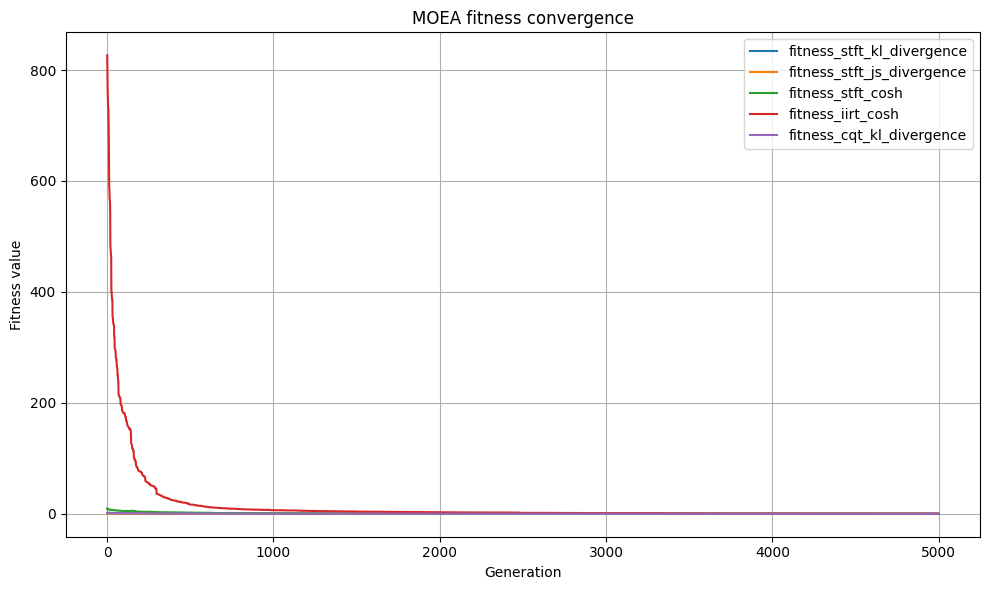

In [11]:
df = moea_experiments[(
    "MOEA",
    "SMSEMOA__stft_kl_divergence__stft_js_divergence__stft_cosh__iirt_cosh__cqt_kl_divergence.csv"
)]
fitness_cols = [
    "fitness_stft_kl_divergence",
    "fitness_stft_js_divergence",
    "fitness_stft_cosh",
    "fitness_iirt_cosh",
    "fitness_cqt_kl_divergence"
]
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for col in fitness_cols:
    plt.plot(df.index, df[col], label=f"{col}")

plt.xlabel("Generation")
plt.ylabel("Fitness value")
plt.title("MOEA fitness convergence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


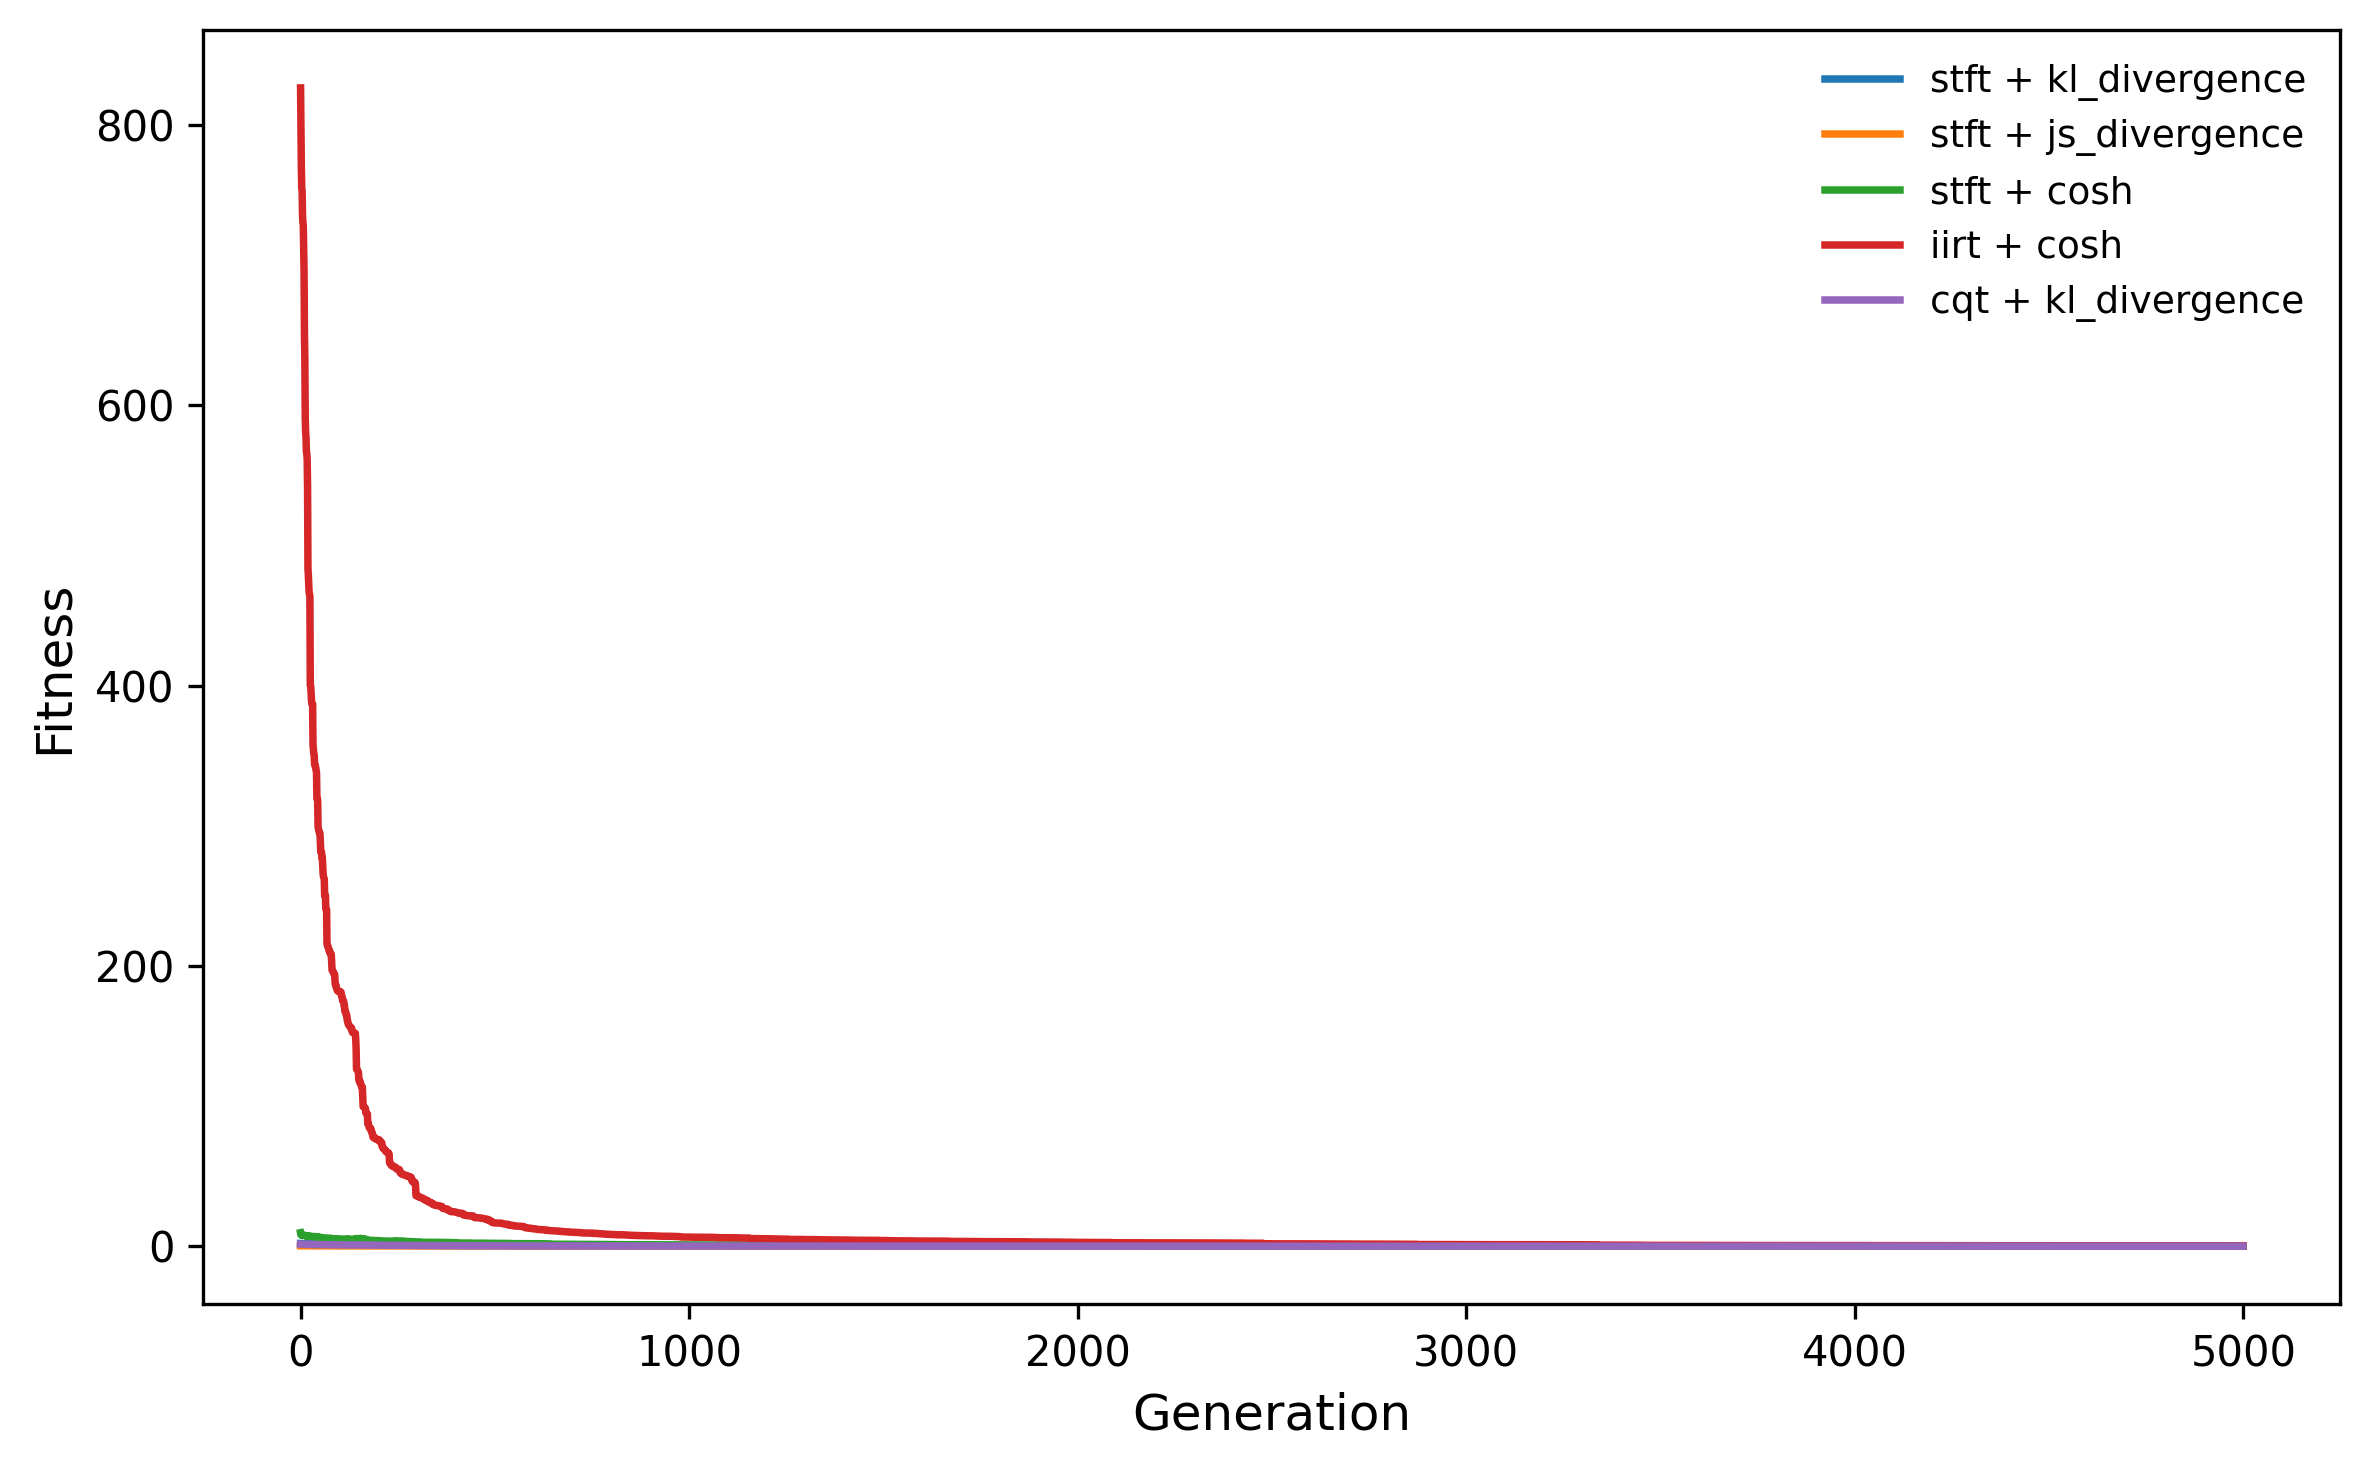

In [12]:
import matplotlib.pyplot as plt
audio_features = [
    "stft", "melspectrogram", "mfcc", "cqt", "vqt",
    "tonnetz", "spectral", "pseudo_cqt", "hybrid_cqt", "iirt"
]

distance_measures = [
    "itakura_saito", "beta_divergence", "cosh", "kl_divergence",
    "js_divergence", "manhattan", "euclidean", "chebyshev",
    "wasserstein", "cosine"
]

def split_objective(obj):
    for dist in distance_measures:
        suffix = "_" + dist
        if obj.endswith(suffix):
            feature = obj[:-len(suffix)]
            if feature in audio_features:
                return feature, dist
    return None, None


# Clean label mapping
def clean_label(col):
    name = col.replace("fitness_", "")
    feature, distance = split_objective(name) 
    return f"{feature} + {distance}"

plt.figure(figsize=(8, 5), dpi=300)

for col in fitness_cols:
    plt.plot(
        df.index,
        df[col],
        linewidth=1.8,
        label=clean_label(col)
    )

plt.xlabel("Generation", fontsize=12)
plt.ylabel("Fitness", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)

plt.grid(False)
plt.tight_layout()

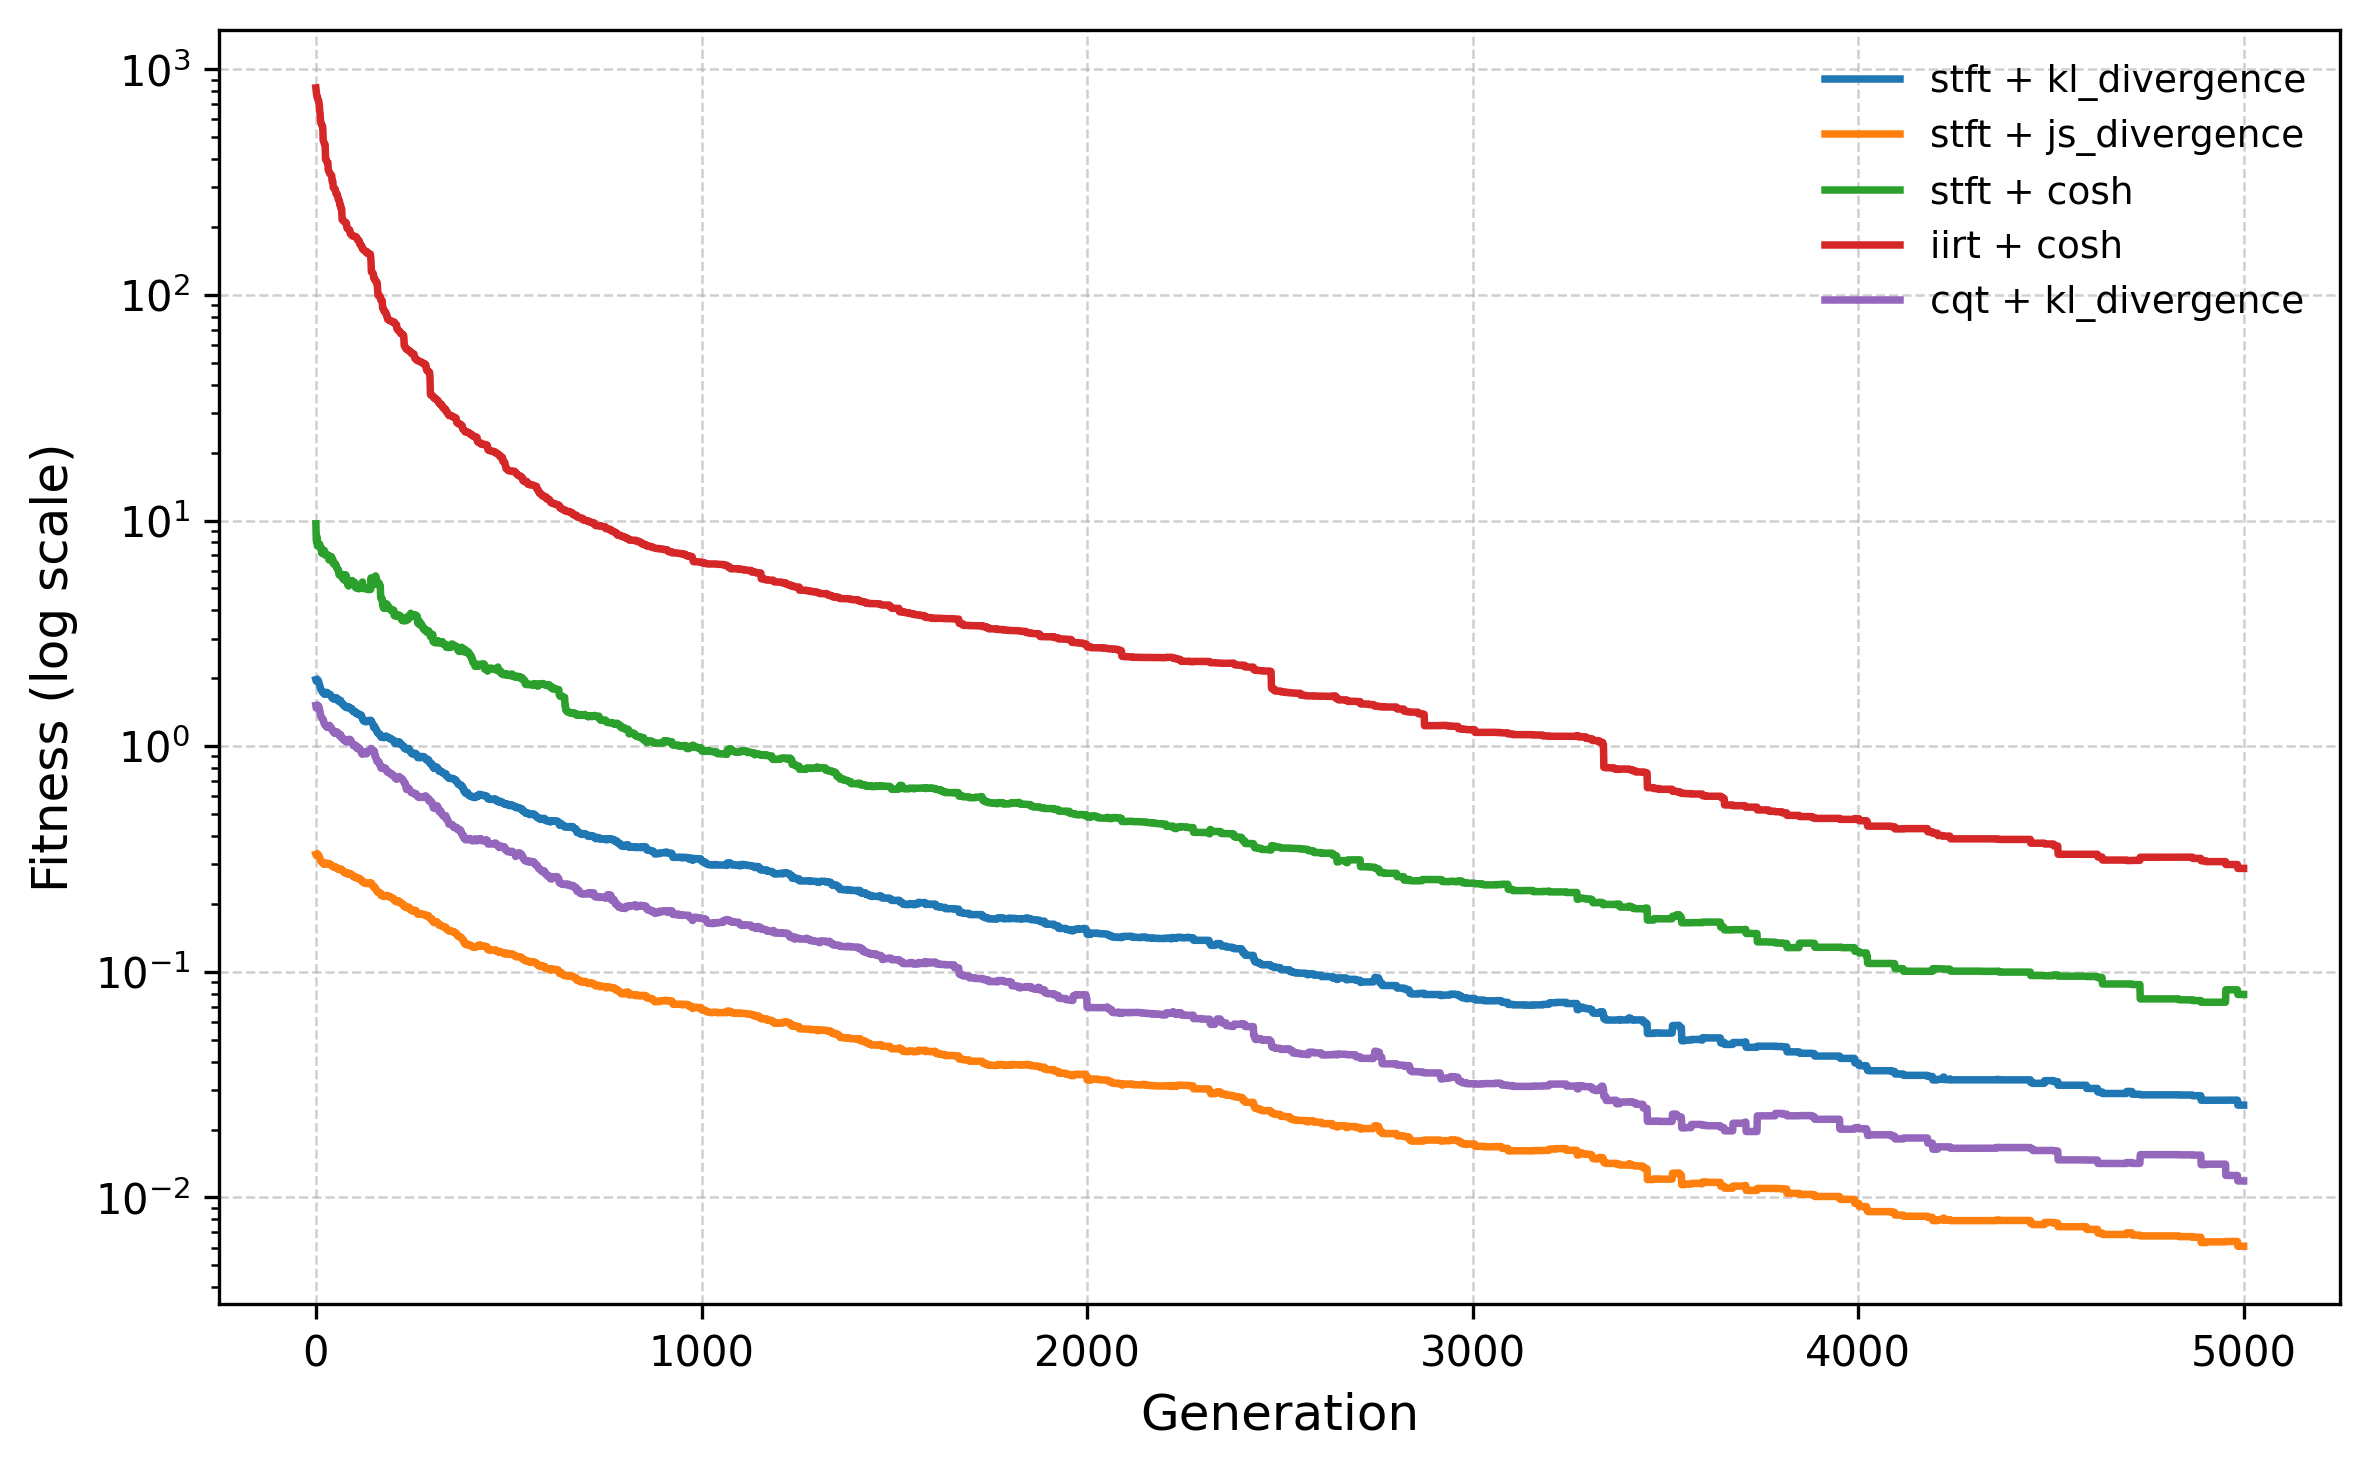

In [13]:
plt.figure(figsize=(8, 5), dpi=300)

for col in fitness_cols:
    plt.plot(
        df.index,
        df[col],
        linewidth=1.8,
        label=clean_label(col)
    )

plt.yscale("log")

plt.xlabel("Generation", fontsize=12)
plt.ylabel("Fitness (log scale)", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.6)

plt.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)

plt.tight_layout()

outdir = os.path.join("experiments", "moea", "plots")
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, "smsemoa_fitness_log.pdf"),
            bbox_inches="tight")
plt.savefig(os.path.join(outdir, "smsemoa_fitness_log.png"),
            dpi=300,
            bbox_inches="tight")

plt.show()

In [23]:
import random

def ensemble_accuracy(indices, M):
    if len(indices) == 0:
        return 0.0
    combined = np.any(M[indices], axis=0)
    return combined.mean()

def approximate_shapley(M, num_samples=5000, seed=None):
    if seed is not None:
        random.seed(seed)
    shapley = np.zeros(100)
    all_indices = list(range(100))
    for _ in range(num_samples):
        perm = random.sample(all_indices, len(all_indices))
        S = set()
        for idx in perm:
            acc_before = ensemble_accuracy(list(S), M)
            S.add(idx)
            acc_after = ensemble_accuracy(list(S), M)
            shapley[idx] += acc_after - acc_before
    return shapley / num_samples

In [27]:
shapley_correct = approximate_shapley(
    np.array(correct_matrix),
    num_samples=100_000,
    seed=1
)

In [24]:
shapley_recall = approximate_shapley(
    np.array(recall_matrix),
    num_samples=100_000,
    seed=1
)

In [28]:
row_labels = [f"{feat}_{dist}" for feat, dist in fitness_labels]
labels = [
    f"{pop_df.iloc[i].audio_feature} | {pop_df.iloc[i].distance}"
    for i in range(len(pop_df))
]

shapley_df = pd.DataFrame(
    {
        "shapley_acc": shapley_correct,
        "shapley_recall": shapley_recall
    },
    index=row_labels
)

shapley_df.sort_values("shapley_acc", ascending=False)

,shapley_acc,shapley_recall
stft_kl_divergence,0.030855,0.026971
pseudo_cqt_js_divergence,0.028693,0.017385
stft_cosh,0.025460,0.023829
stft_js_divergence,0.025023,0.026985
iirt_js_divergence,0.023580,0.017420
hybrid_cqt_js_divergence,0.022311,0.022322
iirt_kl_divergence,0.021602,0.028602
vqt_cosh,0.021018,0.017797
stft_manhattan,0.020787,0.018688
cqt_cosh,0.020531,0.018942


In [29]:
shapley_df.sort_values("shapley_recall", ascending=False)

,shapley_acc,shapley_recall
iirt_kl_divergence,0.021602,0.028602
cqt_js_divergence,0.019511,0.028205
stft_js_divergence,0.025023,0.026985
stft_kl_divergence,0.030855,0.026971
cqt_manhattan,0.019793,0.024707
stft_cosh,0.025460,0.023829
hybrid_cqt_js_divergence,0.022311,0.022322
melspectrogram_manhattan,0.011294,0.022062
cqt_kl_divergence,0.019341,0.021512
iirt_cosh,0.019979,0.021357


In [30]:
shapley_df.to_csv("shapley.csv", index=True)